<a href="https://colab.research.google.com/github/Shrutisru/academic_research/blob/main/week4(A).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Extracting ZIP...
Dataset root : /content/uav_project/data/mav0
সব পাথ ঠিক আছে ✅
OpenCV: 5.0.0
Camera matrix K:
 [[458.654   0.    367.215]
 [  0.    457.296 248.375]
 [  0.      0.      1.   ]]
ব্যবহারযোগ্য ফ্রেম: 3638

[clean] VO শুরু হচ্ছে... (mode=None, severity=moderate)
  [clean] Frame  1000/3638 | Success:   502 | Failed:   498 | Mean confidence (recent): 0.932
  [clean] Frame  1500/3638 | Success:   914 | Failed:   586 | Mean confidence (recent): 0.925
  [clean] Frame  2000/3638 | Success:  1319 | Failed:   681 | Mean confidence (recent): 0.918
  [clean] Frame  2500/3638 | Success:  1736 | Failed:   764 | Mean confidence (recent): 0.898
  [clean] Frame  3500/3638 | Success:  2483 | Failed:  1017 | Mean confidence (recent): 0.927
[clean] সম্পন্ন — ATE RMSE: 3.1467 m | Mean confidence: 0.912 | Failed: 28.7%

[fog] VO শুরু হচ্ছে... (mode=fog, severity=moderate)
  [fog] Frame  1500/3638 | Success:   889 | Failed:   611 | Mean confidence (recent): 0.854
  [

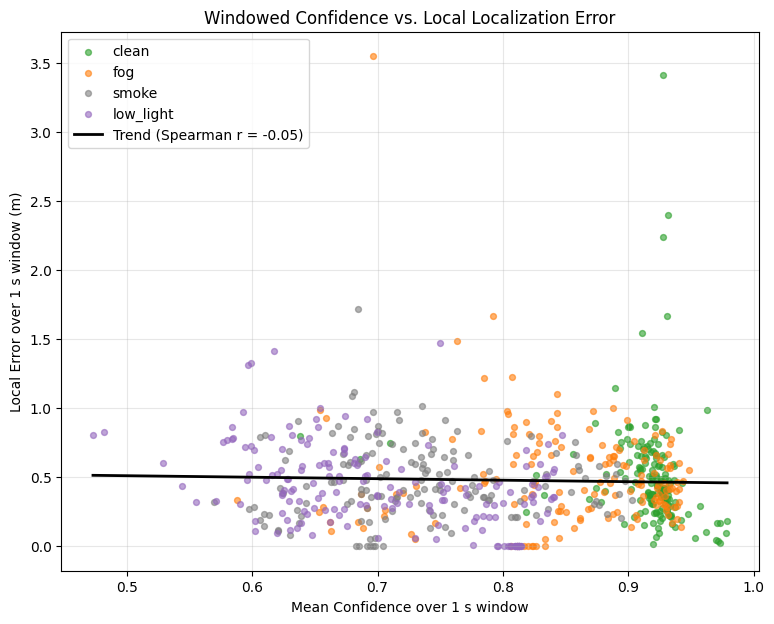

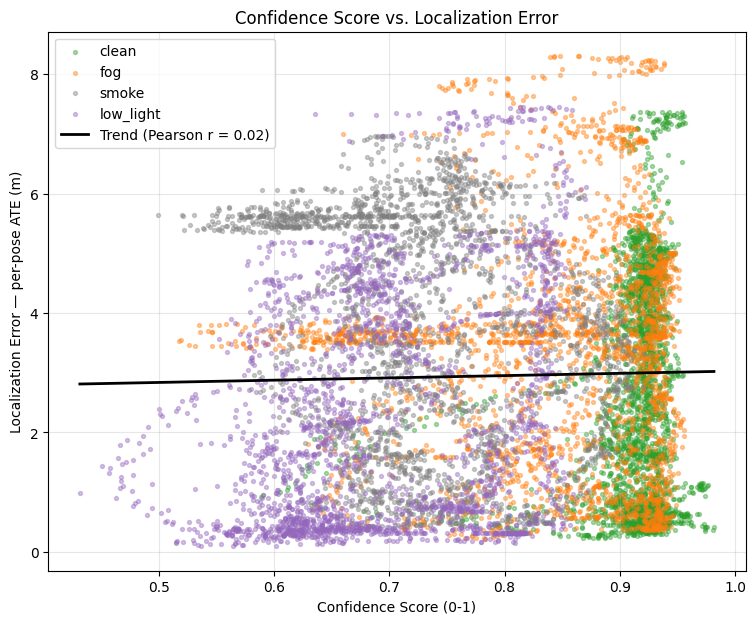

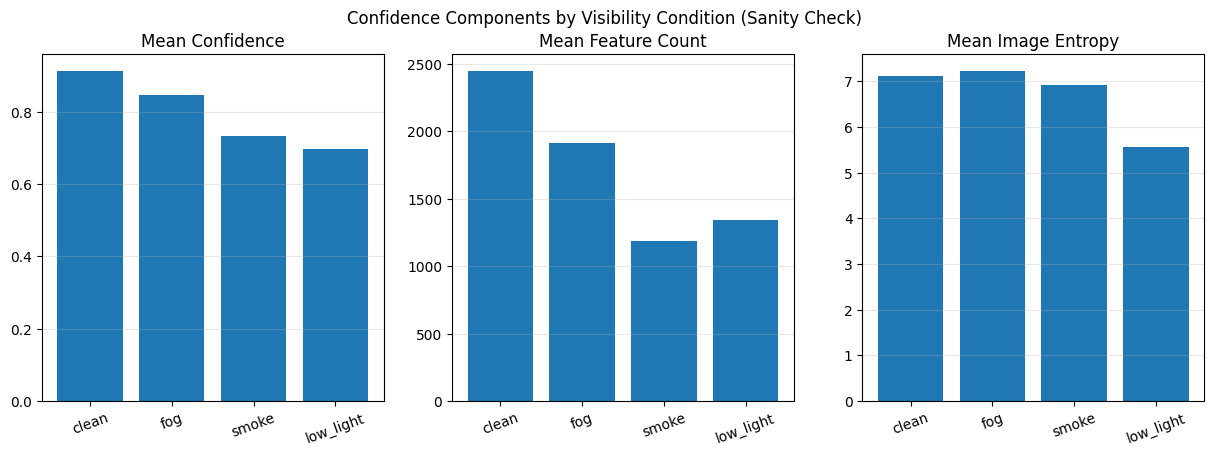


সব ফলাফল সেভ হয়েছে: /content/uav_project/results_week4
যাচাই করুন: Pearson/Spearman r ঋণাত্মক ও উল্লেখযোগ্য (p < 0.05) কিনা,
এবং clean-এর mean confidence low_light-এর চেয়ে বেশি কিনা।


In [1]:
# -*- coding: utf-8 -*-
"""
Week 4 — Per-Modality Confidence Estimator & Correlation with Localization Error
==================================================================================
Week 3-এর VO + degradation পাইপলাইনের উপরেই তৈরি। প্রতিটা সফল ফ্রেমে তিনটা
মেট্রিক থেকে একটা confidence score বানানো হয়:
  - Feature count   (ORB কতগুলো keypoint পেয়েছে)
  - RANSAC inlier ratio  (matching কতটা বিশ্বাসযোগ্য)
  - Image entropy   (ছবিতে কতটা তথ্য/টেক্সচার আছে)

তারপর confidence score-কে সেই একই ফ্রেমের actual localization error
(per-pose ATE, ground truth-এর বিপরীতে) এর সাথে correlate করা হয়।

Colab-এ ধাপে ধাপে (উপর থেকে নিচে) রান করুন।
"""

# ============================================================
# ধাপ ১ — Drive মাউন্ট, ডেটাসেট প্রস্তুত (আগের মতোই)
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import zipfile

zip_path = "/content/drive/MyDrive/MH_01_easy.zip"
work_dir = "/content/uav_project"
extract_dir = f"{work_dir}/data"

os.makedirs(work_dir, exist_ok=True)
assert os.path.exists(zip_path), f"ZIP ফাইল পাওয়া যায়নি: {zip_path}"

dataset_root = None
if os.path.exists(extract_dir):
    for root, dirs, files in os.walk(extract_dir):
        if "mav0" in dirs:
            dataset_root = os.path.join(root, "mav0")
            break

if dataset_root is None:
    os.makedirs(extract_dir, exist_ok=True)
    print("Extracting ZIP...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    for root, dirs, files in os.walk(extract_dir):
        if "mav0" in dirs:
            dataset_root = os.path.join(root, "mav0")
            break

assert dataset_root is not None, "mav0 ফোল্ডার খুঁজে পাওয়া যায়নি।"

cam0_dir = os.path.join(dataset_root, "cam0")
cam0_data = os.path.join(cam0_dir, "data")
cam0_csv = os.path.join(cam0_dir, "data.csv")
sensor_yaml = os.path.join(cam0_dir, "sensor.yaml")
gt_csv = os.path.join(dataset_root, "state_groundtruth_estimate0", "data.csv")

for p in [cam0_data, cam0_csv, sensor_yaml, gt_csv]:
    assert os.path.exists(p), f"পাওয়া যায়নি: {p}"

print("Dataset root :", dataset_root)
print("সব পাথ ঠিক আছে ✅")


# ============================================================
# ধাপ ২ — ইম্পোর্ট ও রেজাল্ট ফোল্ডার
# ============================================================

# !pip install -q opencv-python numpy pandas matplotlib scipy pyyaml

import cv2
import yaml
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from scipy.stats import pearsonr, spearmanr

results_dir = os.path.join(work_dir, "results_week4")
if os.path.exists(results_dir):
    shutil.rmtree(results_dir)
os.makedirs(results_dir, exist_ok=True)

print("OpenCV:", cv2.__version__)

# low_light-এর sensor noise যেন প্রতিবার একই হয় (reproducible ফলাফলের জন্য)
np.random.seed(0)


# ============================================================
# ধাপ ৩ — ক্যালিব্রেশন লোড
# ============================================================

with open(sensor_yaml, "r") as f:
    sensor_data = yaml.safe_load(f)

fx, fy, cx, cy = sensor_data["intrinsics"]
dist_coeffs = np.array(sensor_data["distortion_coefficients"], dtype=np.float64)
K = np.array([[fx, 0.0, cx], [0.0, fy, cy], [0.0, 0.0, 1.0]], dtype=np.float64)

print("Camera matrix K:\n", K)


# ============================================================
# ধাপ ৪ — CSV লোড ও কমন টাইম-উইন্ডো
# ============================================================

cam_df = pd.read_csv(cam0_csv)
gt_df = pd.read_csv(gt_csv)

cam_time_col, cam_file_col = "#timestamp [ns]", "filename"
gt_time_col = "#timestamp"
gt_x_col, gt_y_col, gt_z_col = " p_RS_R_x [m]", " p_RS_R_y [m]", " p_RS_R_z [m]"

cam_df[cam_time_col] = pd.to_numeric(cam_df[cam_time_col])
gt_df[gt_time_col] = pd.to_numeric(gt_df[gt_time_col])

start_time = max(cam_df[cam_time_col].min(), gt_df[gt_time_col].min())
end_time = min(cam_df[cam_time_col].max(), gt_df[gt_time_col].max())
cam_df = cam_df[(cam_df[cam_time_col] >= start_time) &
                (cam_df[cam_time_col] <= end_time)].reset_index(drop=True)

print("ব্যবহারযোগ্য ফ্রেম:", len(cam_df))


# ============================================================
# ধাপ ৫ — Degradation ফাংশন (Week 3 থেকে, low_light fix সহ)
# ============================================================

SEVERITY_PRESETS = {
    "fog": {
        "mild":     {"beta": 0.6, "A": 200},
        "moderate": {"beta": 1.2, "A": 210},
        "severe":   {"beta": 2.0, "A": 220},
    },
    "smoke": {
        "mild":     {"beta": 0.7, "A": 130, "blur": 3},
        "moderate": {"beta": 1.3, "A": 120, "blur": 5},
        "severe":   {"beta": 2.1, "A": 110, "blur": 7},
    },
    "low_light": {
        "mild":     {"gain": 0.65, "gamma": 1.15, "noise_std": 3},
        "moderate": {"gain": 0.45, "gamma": 1.35, "noise_std": 5},
        "severe":   {"gain": 0.28, "gamma": 1.6,  "noise_std": 7},
    },
}


def _depth_proxy(h, w):
    d = np.linspace(1.0, 0.15, h).reshape(h, 1)
    return np.repeat(d, w, axis=1)


def degrade_image(img, mode=None, severity="moderate"):
    if mode is None or mode == "clean":
        return img
    assert mode in SEVERITY_PRESETS, f"অজানা mode: {mode}"
    p = SEVERITY_PRESETS[mode][severity]
    h, w = img.shape[:2]
    img_f = img.astype(np.float32)

    if mode in ("fog", "smoke"):
        depth = _depth_proxy(h, w)
        transmission = np.exp(-p["beta"] * depth).astype(np.float32)
        out = img_f * transmission + p["A"] * (1.0 - transmission)
        if mode == "smoke":
            k = p["blur"]
            out = cv2.GaussianBlur(out, (k, k), 0)
    elif mode == "low_light":
        out = img_f * p["gain"]
        out = 255.0 * np.power(np.clip(out / 255.0, 0, 1), p["gamma"])
        noise = np.random.normal(0, p["noise_std"], out.shape).astype(np.float32)
        out = out + noise

    return np.clip(out, 0, 255).astype(np.uint8)


def load_image(path, mode=None, severity="moderate"):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.undistort(img, K, dist_coeffs)
    return degrade_image(img, mode=mode, severity=severity)


# ============================================================
# ধাপ ৬ — Confidence মেট্রিক ফাংশন (Week 4-এর মূল নতুন অংশ)
# ============================================================

NFEATURES_MAX = 2500   # ORB nfeatures সেটিং, feature-count normalization-এর রেফারেন্স
MAX_ENTROPY = 8.0       # log2(256) — ৮-বিট গ্রেস্কেল ছবির তাত্ত্বিক সর্বোচ্চ entropy


def compute_entropy(img):
    """গ্রেস্কেল ছবির Shannon entropy (বিট্‌স-এ) — কম entropy মানে কম তথ্য/টেক্সচার।"""
    hist = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()
    hist = hist / (hist.sum() + 1e-12)
    hist = hist[hist > 0]
    return float(-np.sum(hist * np.log2(hist)))


def compute_confidence(feature_count, inlier_ratio, entropy):
    """
    তিনটা মেট্রিককে 0-1 রেঞ্জে normalize করে সরল average নেওয়া হচ্ছে।
    (equal weight এখন baseline — future work হিসেবে ওজন টিউন করা যায়)
    """
    norm_feat = min(feature_count / NFEATURES_MAX, 1.0)
    norm_inlier = float(np.clip(inlier_ratio, 0.0, 1.0))
    norm_entropy = float(np.clip(entropy / MAX_ENTROPY, 0.0, 1.0))
    return (norm_feat + norm_inlier + norm_entropy) / 3.0


# ============================================================
# ধাপ ৭ — VO পাইপলাইন + confidence ট্র্যাকিং
# ============================================================

orb = cv2.ORB_create(nfeatures=NFEATURES_MAX, scaleFactor=1.2, nlevels=8,
                     edgeThreshold=31, patchSize=31, fastThreshold=20)
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)

MIN_COMMON_PTS_FOR_SCALE = 6
RATIO_CLIP = (0.2, 5.0)


def build_projection_matrix(K_mat, R_mat, t_vec):
    return K_mat @ np.hstack([R_mat, t_vec.reshape(3, 1)])


def triangulate_points(P1, P2, pts1, pts2):
    pts4d = cv2.triangulatePoints(P1, P2, pts1.T.astype(np.float64), pts2.T.astype(np.float64))
    return (pts4d[:3] / pts4d[3]).T


def run_vo_pipeline(mode=None, severity="moderate", label="clean", verbose=True):
    R_wc = np.eye(3, dtype=np.float64)
    t_wc = np.zeros((3, 1), dtype=np.float64)

    positions, rotations, timestamps = [], [], []
    feature_counts, inlier_ratios, entropies, confidences = [], [], [], []

    first_path = os.path.join(cam0_data, str(cam_df.iloc[0][cam_file_col]))
    prev_img = load_image(first_path, mode=mode, severity=severity)
    assert prev_img is not None, "প্রথম ছবি পড়া যায়নি।"

    prev_kp, prev_des = orb.detectAndCompute(prev_img, None)
    if prev_des is None or len(prev_kp) < 20:
        raise RuntimeError(f"[{label}] প্রথম ফ্রেমে যথেষ্ট ফিচার নেই — severity খুব বেশি হতে পারে।")

    positions.append(t_wc.reshape(3))
    rotations.append(R_wc.copy())
    timestamps.append(int(cam_df.iloc[0][cam_time_col]))
    feature_counts.append(len(prev_kp))
    inlier_ratios.append(np.nan)               # প্রথম ফ্রেমে কোনো matching pair নেই
    entropies.append(compute_entropy(prev_img))
    confidences.append(np.nan)                  # তাই confidence-ও অনির্ধারিত

    successful_pairs, failed_pairs, scale_estimated_count = 0, 0, 0
    inlier_counts = []

    prev_frame_link, prev_R_rel, prev_t_rel = None, None, None
    step_scale = 1.0

    if verbose:
        print(f"\n[{label}] VO শুরু হচ্ছে... (mode={mode}, severity={severity})")

    for i in range(1, len(cam_df)):
        img_path = os.path.join(cam0_data, str(cam_df.iloc[i][cam_file_col]))
        curr_img = load_image(img_path, mode=mode, severity=severity)
        if curr_img is None:
            failed_pairs += 1
            continue

        curr_kp, curr_des = orb.detectAndCompute(curr_img, None)
        if curr_des is None or len(curr_kp) < 20:
            failed_pairs += 1
            prev_frame_link = None
            continue

        try:
            knn_matches = bf.knnMatch(prev_des, curr_des, k=2)
        except cv2.error:
            failed_pairs += 1
            prev_frame_link = None
            continue

        good_matches = [m for pair in knn_matches if len(pair) == 2
                        for m, n in [pair] if m.distance < 0.75 * n.distance]

        if len(good_matches) < 8:
            failed_pairs += 1
            prev_img, prev_kp, prev_des = curr_img, curr_kp, curr_des
            prev_frame_link = None
            continue

        pts_prev = np.float32([prev_kp[m.queryIdx].pt for m in good_matches])
        pts_curr = np.float32([curr_kp[m.trainIdx].pt for m in good_matches])
        prev_idx = np.array([m.queryIdx for m in good_matches])
        curr_idx = np.array([m.trainIdx for m in good_matches])

        E, mask_E = cv2.findEssentialMat(pts_prev, pts_curr, K,
                                         method=cv2.RANSAC, prob=0.999, threshold=1.0)
        if E is None or mask_E is None:
            failed_pairs += 1
            prev_img, prev_kp, prev_des = curr_img, curr_kp, curr_des
            prev_frame_link = None
            continue

        inlier_mask = mask_E.ravel().astype(bool)
        pts_prev_in, pts_curr_in = pts_prev[inlier_mask], pts_curr[inlier_mask]
        prev_idx_in, curr_idx_in = prev_idx[inlier_mask], curr_idx[inlier_mask]
        inlier_counts.append(len(pts_prev_in))

        if len(pts_prev_in) < 8:
            failed_pairs += 1
            prev_img, prev_kp, prev_des = curr_img, curr_kp, curr_des
            prev_frame_link = None
            continue

        try:
            retval, R_rel, t_rel, _ = cv2.recoverPose(E, pts_prev_in, pts_curr_in, K)
        except cv2.error:
            failed_pairs += 1
            prev_img, prev_kp, prev_des = curr_img, curr_kp, curr_des
            prev_frame_link = None
            continue

        if retval < 8:
            failed_pairs += 1
            prev_img, prev_kp, prev_des = curr_img, curr_kp, curr_des
            prev_frame_link = None
            continue

        t_rel_unit = t_rel.reshape(3)

        # --- relative scale propagation (Week 2/3-এর মতোই) ---
        if prev_frame_link is not None and prev_R_rel is not None:
            common_idx = np.intersect1d(prev_idx_in, np.array(list(prev_frame_link.keys())))
            if len(common_idx) >= MIN_COMMON_PTS_FOR_SCALE:
                pts_tm2 = np.array([prev_frame_link[idx] for idx in common_idx], dtype=np.float64)
                pts_tm1 = np.array([prev_kp[idx].pt for idx in common_idx], dtype=np.float64)
                this_map = dict(zip(prev_idx_in.tolist(), pts_curr_in.tolist()))
                pts_t = np.array([this_map[idx] for idx in common_idx], dtype=np.float64)

                P_ref = build_projection_matrix(K, np.eye(3), np.zeros(3))
                P_tm2 = build_projection_matrix(K, prev_R_rel.T, -prev_R_rel.T @ prev_t_rel)
                P_t = build_projection_matrix(K, R_rel, t_rel_unit)

                X_A = triangulate_points(P_tm2, P_ref, pts_tm2, pts_tm1)
                X_B = triangulate_points(P_ref, P_t, pts_tm1, pts_t)

                dist_A, dist_B = pdist(X_A), pdist(X_B)
                valid = ((dist_A > 1e-6) & (dist_B > 1e-6) &
                         np.isfinite(dist_A) & np.isfinite(dist_B))
                if np.any(valid):
                    ratio = float(np.median(dist_A[valid] / dist_B[valid]))
                    step_scale *= float(np.clip(ratio, RATIO_CLIP[0], RATIO_CLIP[1]))
                    scale_estimated_count += 1

        t_rel_scaled = (t_rel_unit * step_scale).reshape(3, 1)
        R_wc = R_wc @ R_rel.T
        t_wc = t_wc - R_wc @ t_rel_scaled

        positions.append(t_wc.reshape(3))
        rotations.append(R_wc.copy())
        timestamps.append(int(cam_df.iloc[i][cam_time_col]))
        successful_pairs += 1

        # --- Week 4: এই ফ্রেমের confidence মেট্রিক রেকর্ড করা ---
        feat_count = len(curr_kp)
        inlier_ratio = len(pts_prev_in) / len(good_matches) if len(good_matches) else 0.0
        ent = compute_entropy(curr_img)
        conf = compute_confidence(feat_count, inlier_ratio, ent)

        feature_counts.append(feat_count)
        inlier_ratios.append(inlier_ratio)
        entropies.append(ent)
        confidences.append(conf)

        prev_frame_link = dict(zip(curr_idx_in.tolist(), pts_prev_in.tolist()))
        prev_R_rel, prev_t_rel = R_rel, t_rel_unit
        prev_img, prev_kp, prev_des = curr_img, curr_kp, curr_des

        if verbose and i % 500 == 0:
            print(f"  [{label}] Frame {i:5d}/{len(cam_df)} | "
                  f"Success: {successful_pairs:5d} | Failed: {failed_pairs:5d} | "
                  f"Mean confidence (recent): {np.nanmean(confidences[-50:]):.3f}")

    total = successful_pairs + failed_pairs
    return {
        "label": label,
        "mode": mode,
        "severity": severity if mode else "-",
        "positions": np.asarray(positions, dtype=np.float64),
        "rotations": np.asarray(rotations, dtype=np.float64),
        "timestamps": np.asarray(timestamps, dtype=np.int64),
        "feature_counts": np.asarray(feature_counts, dtype=np.float64),
        "inlier_ratios": np.asarray(inlier_ratios, dtype=np.float64),
        "entropies": np.asarray(entropies, dtype=np.float64),
        "confidences": np.asarray(confidences, dtype=np.float64),
        "successful_pairs": successful_pairs,
        "failed_pairs": failed_pairs,
        "failed_pct": 100.0 * failed_pairs / total if total else float("nan"),
    }


# ============================================================
# ধাপ ৮ — মূল্যায়ন ফাংশন (alignment + per-pose ATE + RPE)
# ============================================================

gt_time = gt_df[gt_time_col].to_numpy(dtype=np.float64)
gt_position = np.column_stack([
    gt_df[gt_x_col].to_numpy(dtype=np.float64),
    gt_df[gt_y_col].to_numpy(dtype=np.float64),
    gt_df[gt_z_col].to_numpy(dtype=np.float64)
])
gt_time, _uidx = np.unique(gt_time, return_index=True)
gt_position = gt_position[_uidx]


def interpolate_gt(timestamps_ns):
    out = np.zeros((len(timestamps_ns), 3))
    for axis in range(3):
        out[:, axis] = np.interp(timestamps_ns.astype(np.float64), gt_time, gt_position[:, axis])
    return out


def umeyama_alignment(source, target, with_scale=True):
    source, target = np.asarray(source), np.asarray(target)
    n = source.shape[0]
    mu_src, mu_tgt = source.mean(axis=0), target.mean(axis=0)
    src_c, tgt_c = source - mu_src, target - mu_tgt
    cov = (tgt_c.T @ src_c) / n
    U, D, Vt = np.linalg.svd(cov)
    S = np.eye(3)
    if np.linalg.det(U @ Vt) < 0:
        S[-1, -1] = -1
    R = U @ S @ Vt
    scale = (np.sum(D * np.diag(S)) / (np.sum(src_c ** 2) / n)) if with_scale else 1.0
    t = mu_tgt - scale * (R @ mu_src)
    return scale * (R @ source.T).T + t, scale


def evaluate_run(run):
    """per-pose ATE error হিসাব করে run dict-এ যোগ করে — এটাই confidence-এর সাথে মেলানো হবে।"""
    if len(run["positions"]) < 10:
        print(f"  ⚠️ [{run['label']}] মাত্র {len(run['positions'])}টা pose পাওয়া গেছে — "
              f"বাদ দেওয়া হচ্ছে।")
        run.update({"aligned": None, "ate_errors": np.array([]), "ate_rmse": float("nan")})
        return run

    gt_interp = interpolate_gt(run["timestamps"])
    aligned, scale = umeyama_alignment(run["positions"], gt_interp, with_scale=True)
    ate_errors = np.linalg.norm(aligned - gt_interp, axis=1)

    run.update({
        "gt_interp": gt_interp,
        "aligned": aligned,
        "alignment_scale": scale,
        "ate_errors": ate_errors,
        "ate_rmse": float(np.sqrt(np.mean(ate_errors ** 2))),
    })
    return run


# ============================================================
# ধাপ ৯ — ৪টা condition-এ VO + confidence রান
# ============================================================
# ⚠️ ছোট subset-এ আগে টেস্ট করতে চাইলে এই সেলের আগে cam_df = cam_df.iloc[:800] করুন।

SEVERITY = "moderate"

conditions = [
    (None,        "clean"),
    ("fog",       "fog"),
    ("smoke",     "smoke"),
    ("low_light", "low_light"),
]

runs = []
for mode, label in conditions:
    run = run_vo_pipeline(mode=mode, severity=SEVERITY, label=label)
    run = evaluate_run(run)
    runs.append(run)
    mean_conf = np.nanmean(run["confidences"])
    print(f"[{label}] সম্পন্ন — ATE RMSE: {run['ate_rmse']:.4f} m | "
          f"Mean confidence: {mean_conf:.3f} | Failed: {run['failed_pct']:.1f}%")


# ============================================================
# ধাপ ১০ — Confidence vs Error ডেটা একত্র করা ও correlation হিসাব
# ============================================================

rows = []
for r in runs:
    if r["aligned"] is None:
        continue
    n = len(r["positions"])
    for i in range(n):
        conf = r["confidences"][i]
        err = r["ate_errors"][i] if i < len(r["ate_errors"]) else np.nan
        if np.isnan(conf) or np.isnan(err):
            continue
        rows.append({
            "condition": r["label"],
            "confidence": conf,
            "error_m": err,
            "feature_count": r["feature_counts"][i],
            "inlier_ratio": r["inlier_ratios"][i],
            "entropy": r["entropies"][i],
        })

df = pd.DataFrame(rows)
df.to_csv(os.path.join(results_dir, "confidence_vs_error.csv"), index=False)

pearson_r, pearson_p = pearsonr(df["confidence"], df["error_m"])
spearman_r, spearman_p = spearmanr(df["confidence"], df["error_m"])

print("\n" + "=" * 70)
print("WEEK 4 — Confidence vs Localization Error CORRELATION (pooled, সব condition)")
print("=" * 70)
print(f"মোট ডেটা পয়েন্ট: {len(df)}")
print(f"Pearson r  : {pearson_r:.4f}  (p = {pearson_p:.2e})")
print(f"Spearman r : {spearman_r:.4f}  (p = {spearman_p:.2e})")
print("(ঋণাত্মক মান প্রত্যাশিত — confidence বেশি মানে error কম)")

print("\nপ্রতিটা condition-এ আলাদাভাবে:")
per_condition_rows = []
for label in df["condition"].unique():
    sub = df[df["condition"] == label]
    if len(sub) < 5:
        continue
    r_p, p_p = pearsonr(sub["confidence"], sub["error_m"])
    r_s, p_s = spearmanr(sub["confidence"], sub["error_m"])
    per_condition_rows.append({
        "condition": label, "n": len(sub),
        "mean_confidence": round(sub["confidence"].mean(), 3),
        "mean_error_m": round(sub["error_m"].mean(), 3),
        "pearson_r": round(r_p, 3), "spearman_r": round(r_s, 3),
    })
per_condition_df = pd.DataFrame(per_condition_rows)
print(per_condition_df.to_string(index=False))
per_condition_df.to_csv(os.path.join(results_dir, "per_condition_correlation.csv"), index=False)


# ------------------------------------------------------------
# ধাপ ১০-খ — শক্তিশালী যাচাই: ~১ সেকেন্ডের non-overlapping window-ভিত্তিক বিশ্লেষণ
# ------------------------------------------------------------
# কেন দরকার? উপরের per-pose ATE হলো জমে-থাকা (cumulative) drift — ফ্রেম i-এর error আসলে
# আগের সব ধাপের ভুলের সমষ্টি, শুধু ফ্রেম i-এর মান নয়। তাই এক ফ্রেমের confidence-এর সাথে
# এর সম্পর্ক দুর্বল দেখাতে পারে। এছাড়া পরপর ফ্রেমগুলো স্বাধীন না (autocorrelated), তাই
# p-value বেশি আশাবাদী আসে। ~১ সেকেন্ডের window-এর গড় confidence বনাম সেই window-এর
# local (relative) error মেলালে দুটো সমস্যাই কমে — এটাই বেশি বিশ্বাসযোগ্য প্রমাণ।

WINDOW_SEC = 1.0
window_ns = int(WINDOW_SEC * 1e9)
window_rows = []

for r in runs:
    if r["aligned"] is None:
        continue
    ts, conf = r["timestamps"], r["confidences"]
    aligned, gt = r["aligned"], r["gt_interp"]
    start = 0
    while start < len(ts) - 1:
        end = int(np.searchsorted(ts, ts[start] + window_ns))
        if end >= len(ts):
            break
        seg = conf[start:end + 1]
        seg = seg[~np.isnan(seg)]
        if len(seg) > 0:
            local_err = float(np.linalg.norm(
                (aligned[end] - aligned[start]) - (gt[end] - gt[start])))
            ir = r["inlier_ratios"][start:end + 1]
            ir = ir[~np.isnan(ir)]
            window_rows.append({
                "condition": r["label"],
                "confidence": float(seg.mean()),
                "feature_count": float(np.mean(r["feature_counts"][start:end + 1])),
                "inlier_ratio": float(ir.mean()) if len(ir) else np.nan,
                "entropy": float(np.mean(r["entropies"][start:end + 1])),
                "local_error_m": local_err,
            })
        start = end

wdf = pd.DataFrame(window_rows)
wdf.to_csv(os.path.join(results_dir, "windowed_confidence_vs_local_error.csv"), index=False)

print("\n" + "=" * 70)
print(f"WEEK 4 — WINDOWED বিশ্লেষণ (~{WINDOW_SEC:.0f}s window, local error)")
print("=" * 70)
if len(wdf) >= 5:
    w_pearson, w_pearson_p = pearsonr(wdf["confidence"], wdf["local_error_m"])
    w_spearman, w_spearman_p = spearmanr(wdf["confidence"], wdf["local_error_m"])
    print(f"মোট window: {len(wdf)}")
    print(f"Pearson r  : {w_pearson:.4f}  (p = {w_pearson_p:.2e})")
    print(f"Spearman r : {w_spearman:.4f}  (p = {w_spearman_p:.2e})")

    print("\nপ্রতিটা condition-এ আলাদাভাবে (windowed):")
    for label in wdf["condition"].unique():
        sub = wdf[wdf["condition"] == label]
        if len(sub) >= 5:
            r_s, p_s = spearmanr(sub["confidence"], sub["local_error_m"])
            print(f"  {label:10s} n={len(sub):4d}  Spearman r = {r_s:+.3f}  (p = {p_s:.2e})")

    # --- কোন মেট্রিক আসলে local error predict করে? (Week 4-এর "study" অংশের মূল প্রশ্ন) ---
    print("\nকোন মেট্রিক local error predict করে? (window-ভিত্তিক Spearman r)")
    header = f"  {'metric':14s} {'pooled':>8s}"
    for label in wdf["condition"].unique():
        header += f" {label:>10s}"
    print(header)
    for col in ["feature_count", "inlier_ratio", "entropy", "confidence"]:
        valid = wdf.dropna(subset=[col])
        r_all, _ = spearmanr(valid[col], valid["local_error_m"])
        line = f"  {col:14s} {r_all:+8.3f}"
        for label in wdf["condition"].unique():
            sub = valid[valid["condition"] == label]
            r_c = spearmanr(sub[col], sub["local_error_m"])[0] if len(sub) >= 5 else float("nan")
            line += f" {r_c:+10.3f}"
        print(line)

    # --- condition-এর প্রভাব বাদ দিয়ে pooled সম্পর্ক ---
    # প্রতিটা condition-এর নিজের গড় বাদ দিয়ে (demean) তারপর একত্র করা হচ্ছে, যাতে
    # "কোন condition-এ আছি" এই পার্থক্য (confound) সম্পর্কটাকে চাপা না দেয়।
    wdf["conf_within"] = wdf["confidence"] - wdf.groupby("condition")["confidence"].transform("mean")
    wdf["err_within"] = wdf["local_error_m"] - wdf.groupby("condition")["local_error_m"].transform("mean")
    rw_s, rw_p = spearmanr(wdf["conf_within"], wdf["err_within"])
    rw_p_r, rw_p_p = pearsonr(wdf["conf_within"], wdf["err_within"])
    print(f"\nWithin-condition (condition-গড় বাদ দিয়ে) pooled: "
          f"Spearman r = {rw_s:+.3f} (p = {rw_p:.2e}), Pearson r = {rw_p_r:+.3f} (p = {rw_p_p:.2e})")

    plt.figure(figsize=(9, 7))
    w_colors = {"clean": "tab:green", "fog": "tab:orange", "smoke": "tab:gray", "low_light": "tab:purple"}
    for label in wdf["condition"].unique():
        sub = wdf[wdf["condition"] == label]
        plt.scatter(sub["confidence"], sub["local_error_m"], s=18, alpha=0.6,
                    label=label, color=w_colors.get(label))
    w_coeffs = np.polyfit(wdf["confidence"], wdf["local_error_m"], 1)
    w_x = np.linspace(wdf["confidence"].min(), wdf["confidence"].max(), 100)
    plt.plot(w_x, np.polyval(w_coeffs, w_x), color="black", linewidth=2,
             label=f"Trend (Spearman r = {w_spearman:.2f})")
    plt.xlabel("Mean Confidence over 1 s window")
    plt.ylabel("Local Error over 1 s window (m)")
    plt.title("Windowed Confidence vs. Local Localization Error")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(results_dir, "windowed_confidence_vs_local_error.png"),
                dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("window সংখ্যা খুব কম — বিশ্লেষণ বাদ দেওয়া হলো।")


# ============================================================
# ধাপ ১১ — Scatter প্লট: Confidence vs Error (Presentation 4-এর মূল ডেলিভারেবল)
# ============================================================

plt.figure(figsize=(9, 7))
colors = {"clean": "tab:green", "fog": "tab:orange", "smoke": "tab:gray", "low_light": "tab:purple"}
for label in df["condition"].unique():
    sub = df[df["condition"] == label]
    plt.scatter(sub["confidence"], sub["error_m"], s=8, alpha=0.4,
                label=label, color=colors.get(label))

# পুরো pooled ডেটার উপর একটা রিগ্রেশন লাইন
coeffs = np.polyfit(df["confidence"], df["error_m"], 1)
x_line = np.linspace(df["confidence"].min(), df["confidence"].max(), 100)
plt.plot(x_line, np.polyval(coeffs, x_line), color="black", linewidth=2,
         label=f"Trend (Pearson r = {pearson_r:.2f})")

plt.xlabel("Confidence Score (0-1)")
plt.ylabel("Localization Error — per-pose ATE (m)")
plt.title("Confidence Score vs. Localization Error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(results_dir, "confidence_vs_error_scatter.png"), dpi=200, bbox_inches="tight")
plt.show()


# ============================================================
# ধাপ ১২ — স্যানিটি চেক: condition অনুযায়ী গড় confidence
# ============================================================
# প্রত্যাশা: clean সবচেয়ে বেশি confidence দেখাবে, low_light সবচেয়ে কম

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics = [("confidence", "Mean Confidence"), ("feature_count", "Mean Feature Count"),
           ("entropy", "Mean Image Entropy")]
for ax, (col, title) in zip(axes, metrics):
    means = df.groupby("condition")[col].mean().reindex(["clean", "fog", "smoke", "low_light"])
    ax.bar(means.index.astype(str), means.values)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(True, axis="y", alpha=0.3)
plt.suptitle("Confidence Components by Visibility Condition (Sanity Check)")
plt.savefig(os.path.join(results_dir, "confidence_components_by_condition.png"),
            dpi=200, bbox_inches="tight")
plt.show()

print("\nসব ফলাফল সেভ হয়েছে:", results_dir)
print("যাচাই করুন: Pearson/Spearman r ঋণাত্মক ও উল্লেখযোগ্য (p < 0.05) কিনা,")
print("এবং clean-এর mean confidence low_light-এর চেয়ে বেশি কিনা।")